# Notebook to plot results from a `tdinf` run

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", "UserWarning")

import numpy as np 
import scipy.linalg as sl

# for plotting
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

from tdinf import group_postprocess, utils, run_sampler, waveform_h5s

### Load in result

Results from `tdinf` runs can easily be loaded in using the `group_postprocess` module:

In [3]:
# Load in the result
result = group_postprocess.load_run_settings_from_directory('output')

/Users/kylakelley/Documents/Research/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/Users/kylakelley/Documents/Research/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/Users/kylakelley/Documents/Research/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"


The result object has helpful keys:
- `dir` tells you the directory where the output lives, relative to this notebook
- `runs` has `args`, `kwargs` and the `likelihood_manager` for the run corresponding to each cutoff time (including `full`)
- `dfs` has `pandas` `DataFrame`s containing the posterior samples for the run for each cutoff time

In [4]:
# Extract the likelihood_manager for easy use
lm = result['runs']['full']['likelihood_manager']

The different runs are labeled as follows: 
- full data: `full`
- pre cutoff: `pre_XX`
- post cutoff: `post_XX`
This can be seen by printing out the keys to `result['dfs']`:

In [5]:
result['dfs'].keys()

dict_keys(['pre_0.0', 'pre_-0.6', 'full', 'pre_-0.4', 'pre_-0.2'])

### Plot posterior distributions for the full run and pre/post cutoff times

Let's plot posterior distributions for each of the 15 binary black hole parameters:

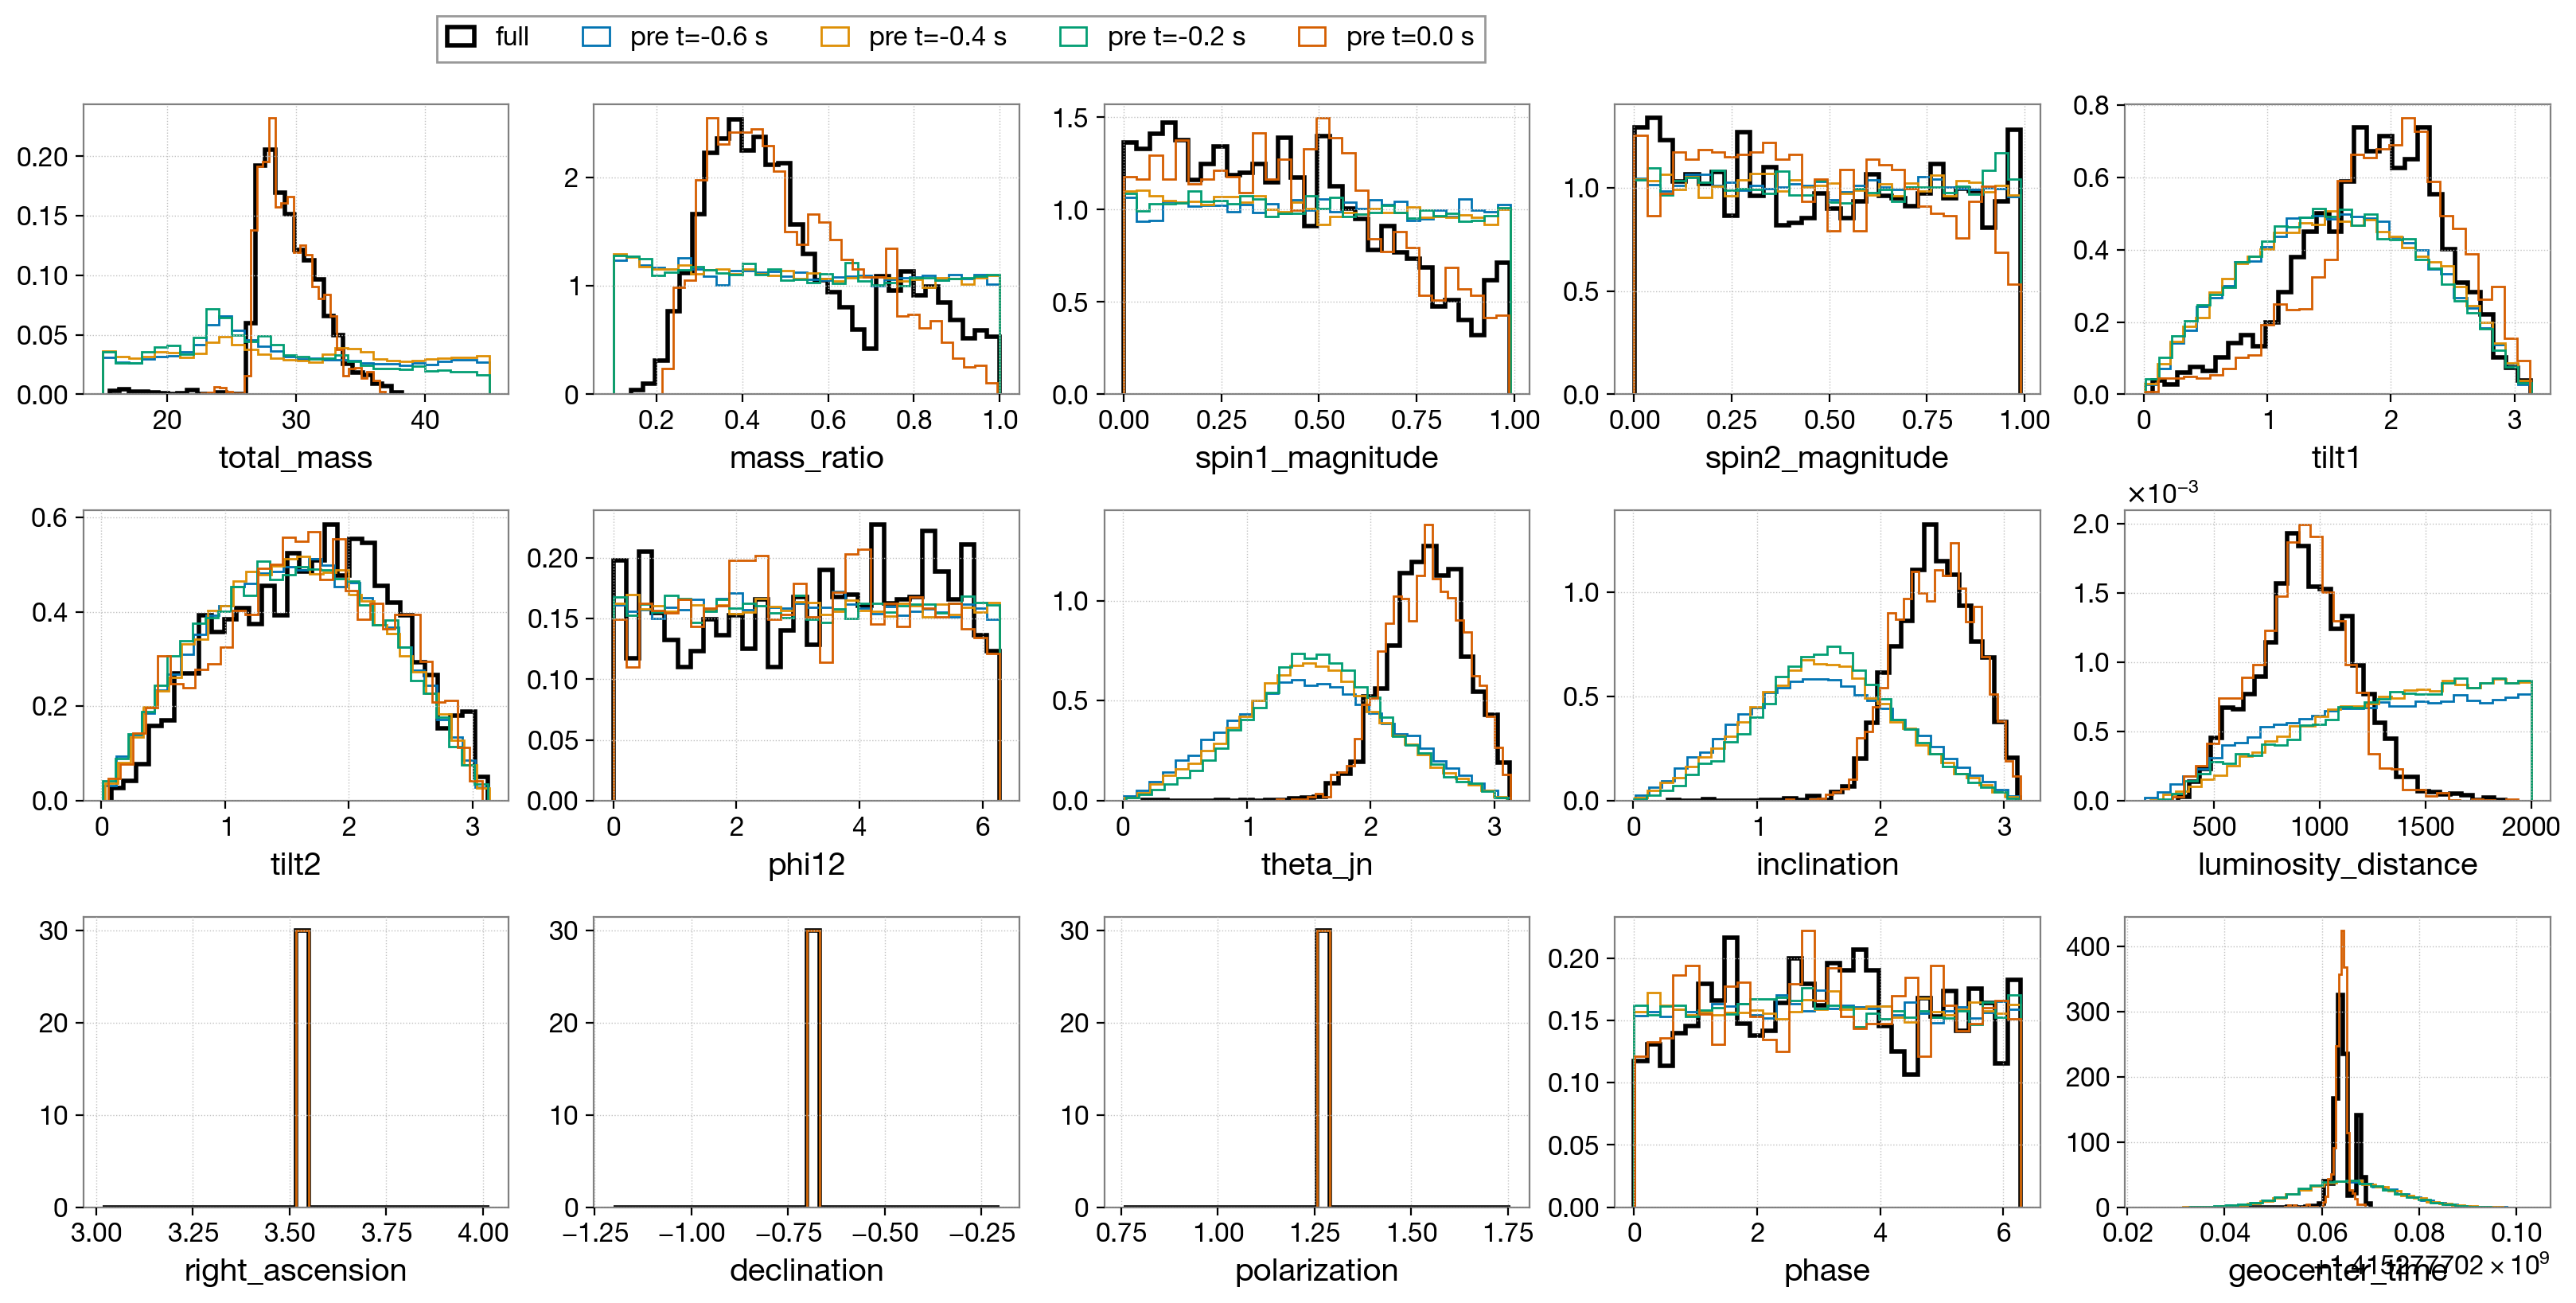

In [6]:
params_to_plot = ['total_mass', 'mass_ratio', 'spin1_magnitude', 'spin2_magnitude',
           'tilt1', 'tilt2', 'phi12', 'theta_jn', 'inclination','luminosity_distance',  
                  'right_ascension', 'declination', 'polarization', 'phase', 'geocenter_time']

fig, axes = plt.subplots(3,5,figsize=(20,9))

for ax, p in zip(axes.flatten(), params_to_plot):
    
    hist_kws = dict(density=True, histtype='step', bins=30) 

    ax.hist(result['dfs']['full'][p], **hist_kws, lw=2, color='k', label='full')

    ax.hist(result['dfs']['pre_-0.6'][p], **hist_kws, label='pre t=-0.6 s', color='C0')
    ax.hist(result['dfs']['pre_-0.4'][p], **hist_kws, label='pre t=-0.4 s', color='C1')
    ax.hist(result['dfs']['pre_-0.2'][p], **hist_kws, label='pre t=-0.2 s', color='C2')
    ax.hist(result['dfs']['pre_0.0'][p], **hist_kws, label='pre t=0.0 s', color='C3')
    
    ax.set_xlabel(p)
    ax.grid(color='silver', ls=':')

axes[0][0].legend(ncols=7, loc='lower left', bbox_to_anchor=(0.8,1.1))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

From these we are see at what cutoff times information about various parameters is gained or lost. For example, we constrain but slightly under-estimate the total mass for the `pre_0.05` run, while we over-estimate it for `post_-0.05` and `post_0.0`. For other cutoffs, we return the prior, meaning there is not information about total mass looking at, e.g., just the `post_0.05` data.

### Plot strain and waveform reconstructions

For easy visualization, let's generate the whitened strain. We can easily whiten data using the `utils` module. 

In [7]:
# Get whitened strain 
data_dict_wh =  utils.whitenData_dict_TD(lm.data_dict, lm)

Next, load in the waveform reconstructions for these runs with the `waveform_h5s` module, and again whiten them.

In [8]:
# Load waveform reconstructions from the full run
wfs_full = waveform_h5s.load_waveform_h5py(f'output/waveforms/full_waveforms.h5')

wfs_0 = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_0.0_waveforms.h5')
wfs_2 = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_-0.2_waveforms.h5')
wfs_4 = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_-0.4_waveforms.h5')
wfs_6 = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_-0.6_waveforms.h5')

In [9]:
# Whiten waveform reconstructions
L_dict= {} # first, make a Cholesky decomposition of the Toeplitz matrix from the ACF for quick whitening
for ifo in lm.ifos:
    C = sl.toeplitz(lm.rho_dict[ifo])
    L_dict[ifo] = sl.cholesky(C,lower=True)
    
wfs_full_whitened = utils.whiten_wfs_TD(wfs_full['samples'], L_dict)
wfs_0_whitened = utils.whiten_wfs_TD(wfs_0['samples'], L_dict)
wfs_2_whitened = utils.whiten_wfs_TD(wfs_2['samples'], L_dict)
wfs_4_whitened = utils.whiten_wfs_TD(wfs_4['samples'], L_dict)
wfs_6_whitened = utils.whiten_wfs_TD(wfs_6['samples'], L_dict)

100%|███████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 63.04it/s]


To plot our reconstructions as a function of time from merger, we also need the delay times for each detector. These can be generated using the `likelihood_manager` and the reference time and sky position for our run.

In [10]:
# Get detector delay times 
dt_dict = lm.waveform_manager.antenna_and_time_manager.compute_time_delay_dict(
    result['runs']['full']['kwargs']['right_ascension'], 
    result['runs']['full']['kwargs']['declination'], 
    lm.reference_time, 
    lm.ifos
)

Plot full reconstructions:

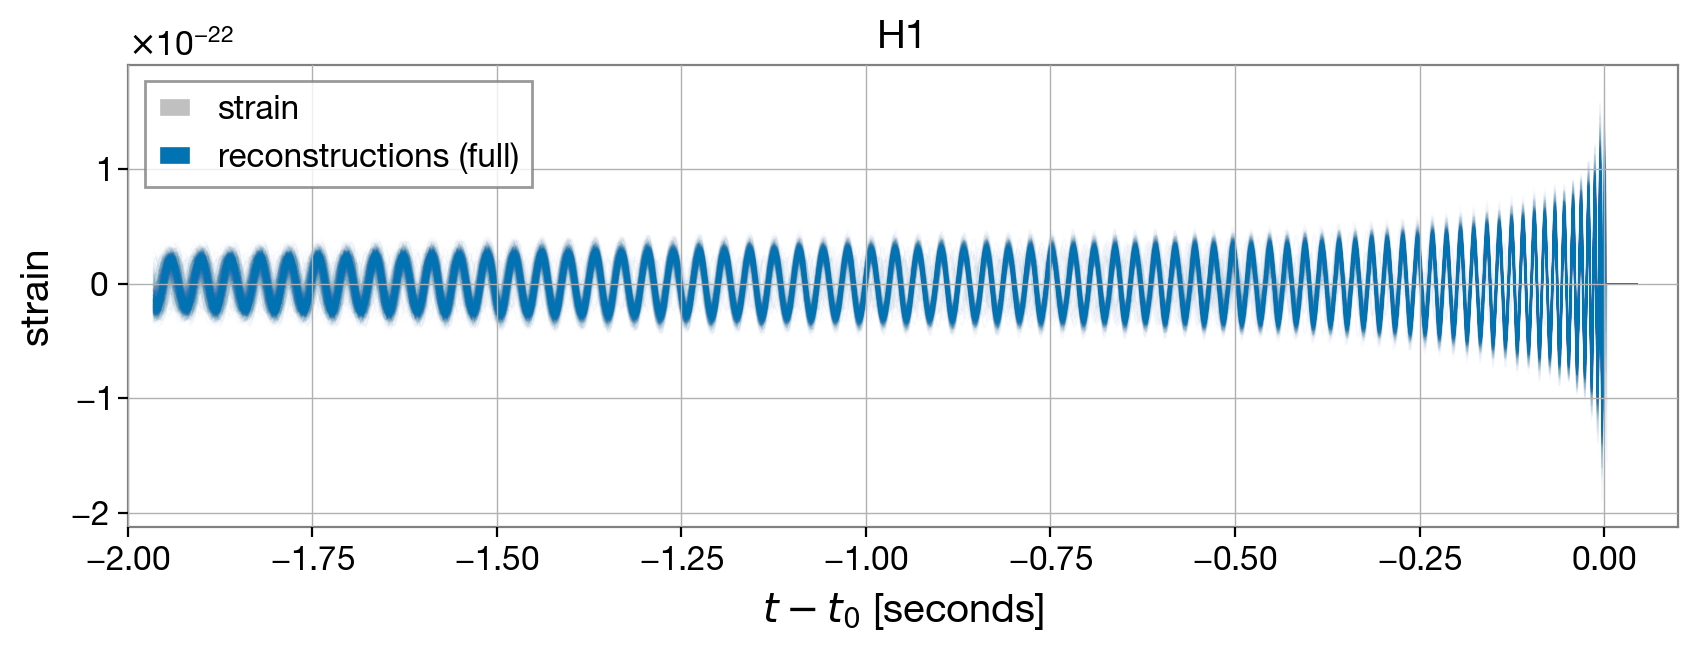

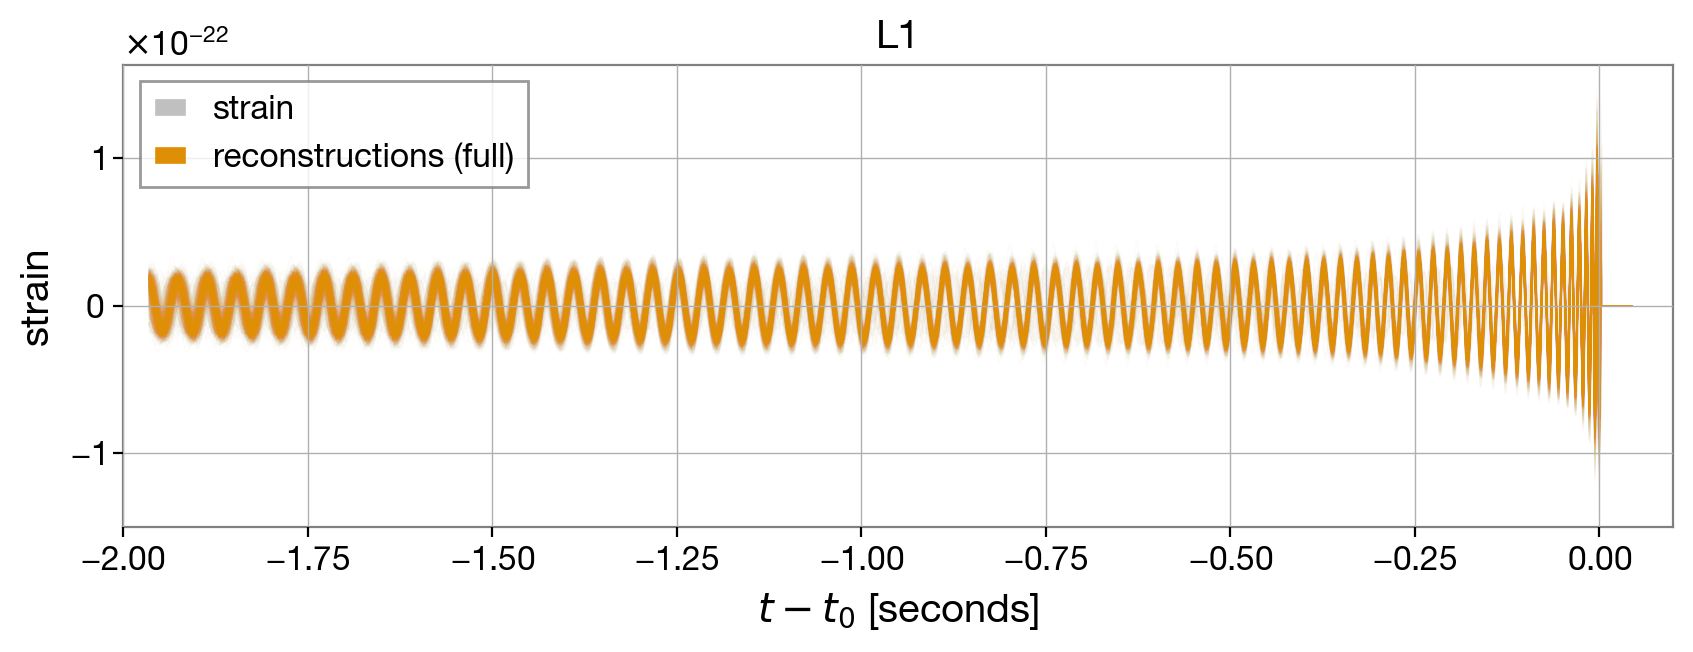

In [11]:
for i, ifo in enumerate(lm.ifos): 

    plt.figure(figsize=(10, 3))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    
    # plt.plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    
    for j in range(len(wfs_full['samples'])):
        plt.plot(time_from_merger, wfs_full['samples'][j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)

    plt.title(ifo)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    plt.legend(handles=handles)
    plt.xlim(-2, 0.1)
    plt.xlabel('$t-t_0$ [seconds]')
    plt.ylabel('strain')
    plt.show()

/Users/kylakelley/Documents/Research/tdinf/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


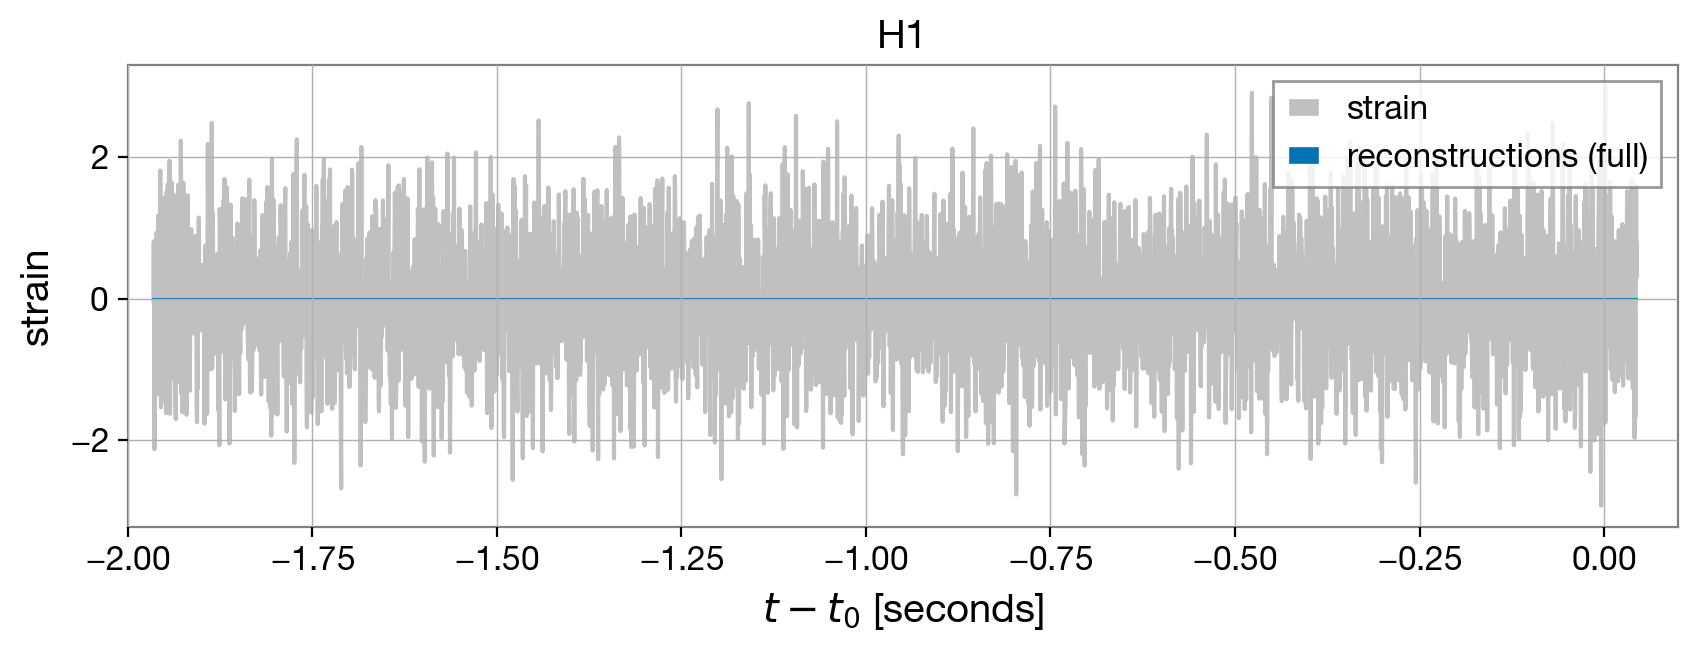

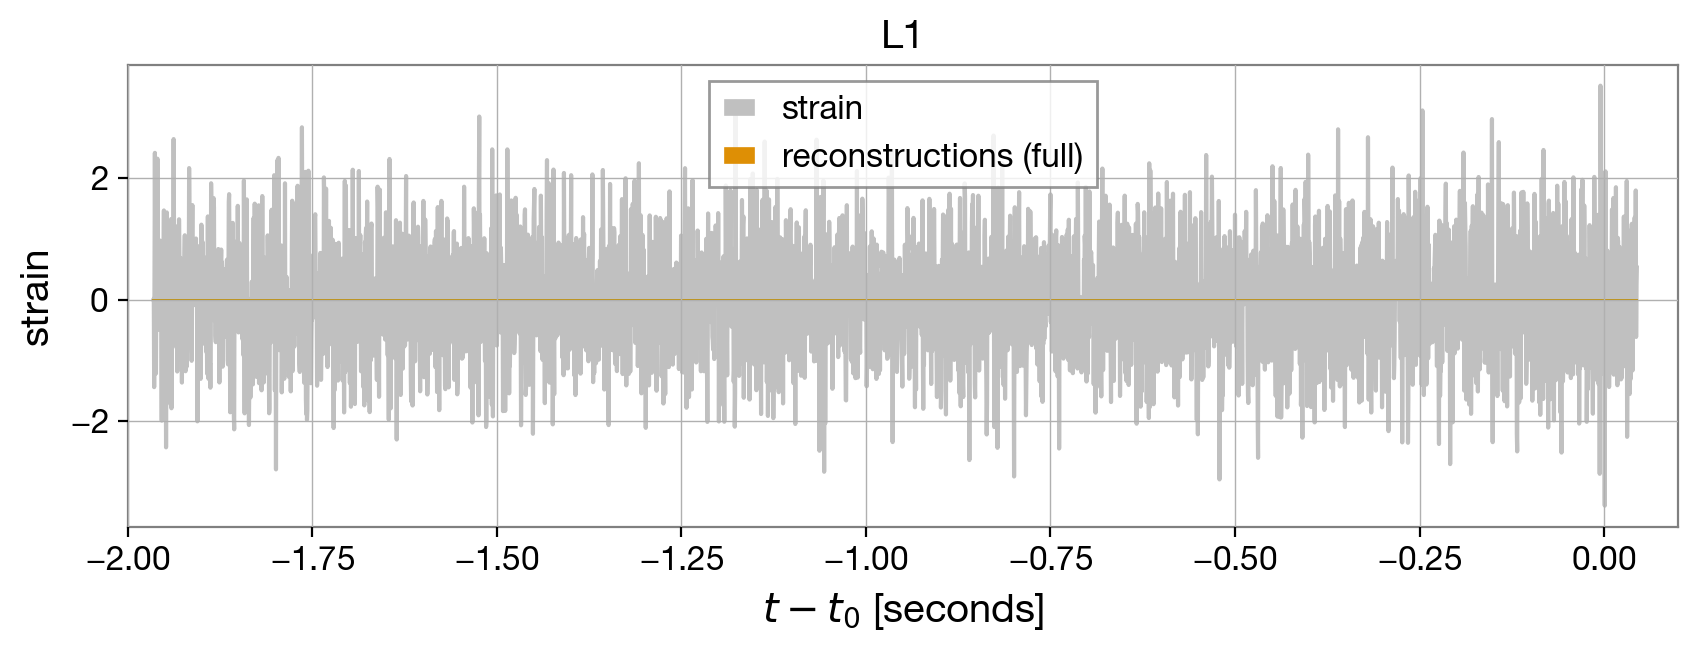

In [12]:
for i, ifo in enumerate(lm.ifos): 

    plt.figure(figsize=(10, 3))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    
    plt.plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    
    for j in range(len(wfs_full['samples'])):
        plt.plot(time_from_merger, wfs_full['samples'][j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)

    plt.title(ifo)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    plt.legend(handles=handles)
    plt.xlim(-2, 0.1)
    plt.xlabel('$t-t_0$ [seconds]')
    plt.ylabel('strain')
    plt.show()

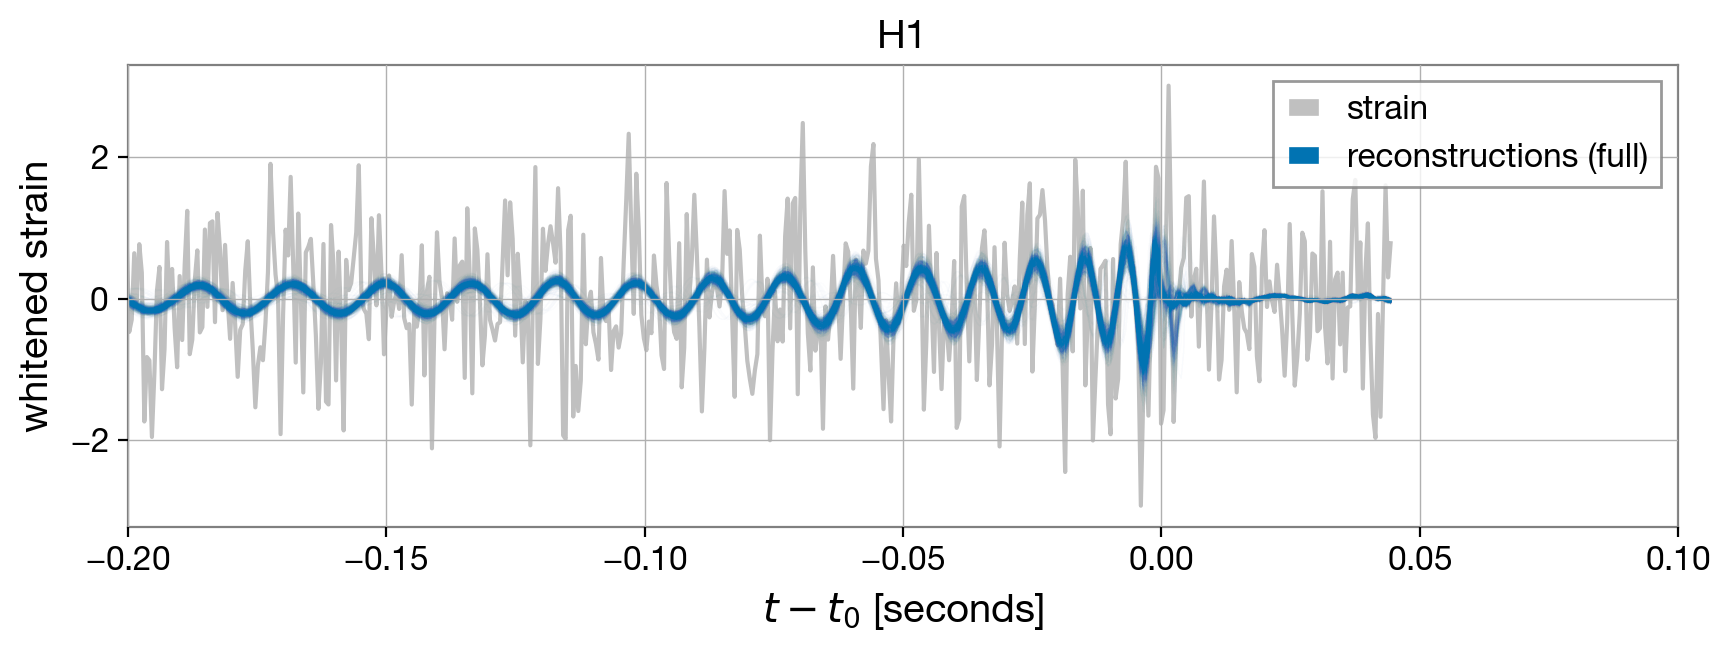

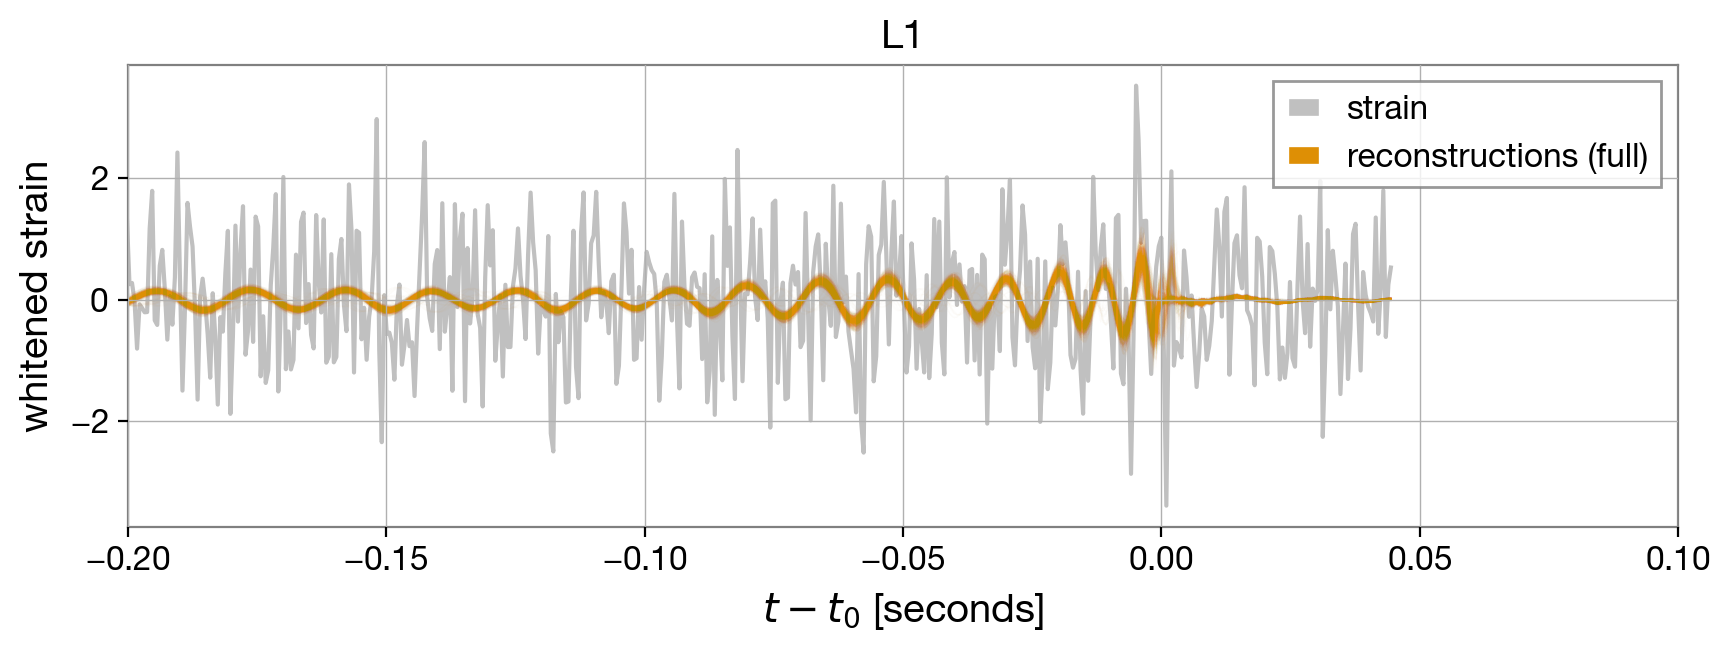

In [13]:
for i, ifo in enumerate(lm.ifos): 

    plt.figure(figsize=(10, 3))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    
    plt.plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    
    for j in range(len(wfs_full['samples'])):
        plt.plot(time_from_merger, wfs_full_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)

    plt.title(ifo)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    plt.legend(handles=handles)
    plt.xlim(-0.2, 0.1)
    plt.xlabel('$t-t_0$ [seconds]')
    plt.ylabel('whitened strain')
    plt.show()

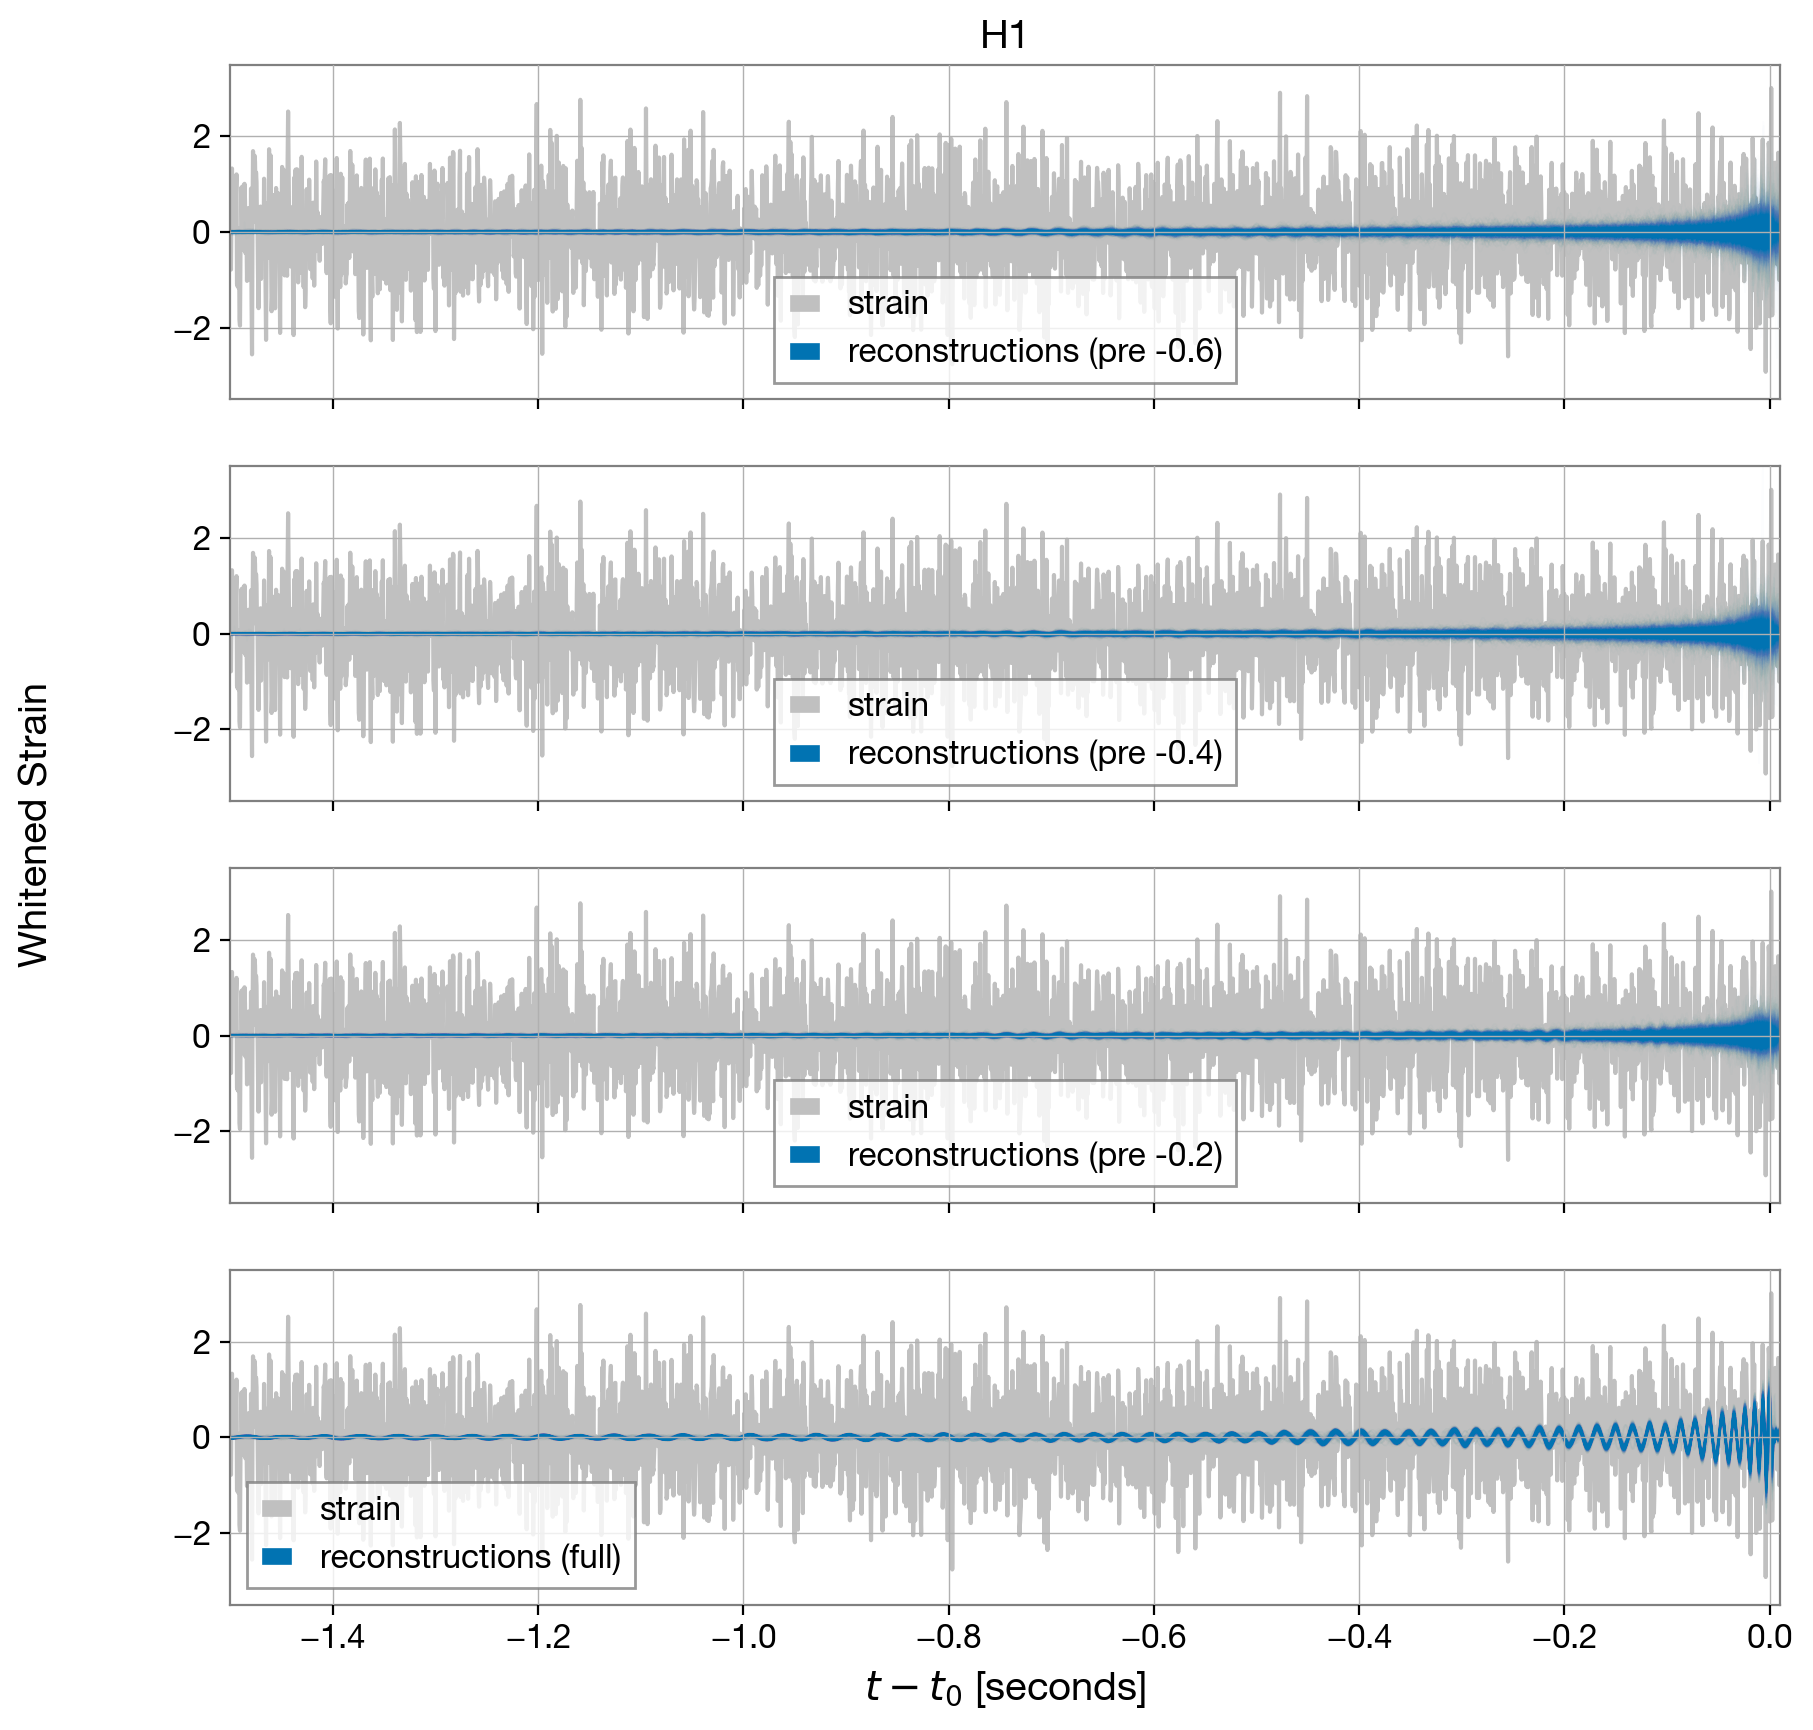

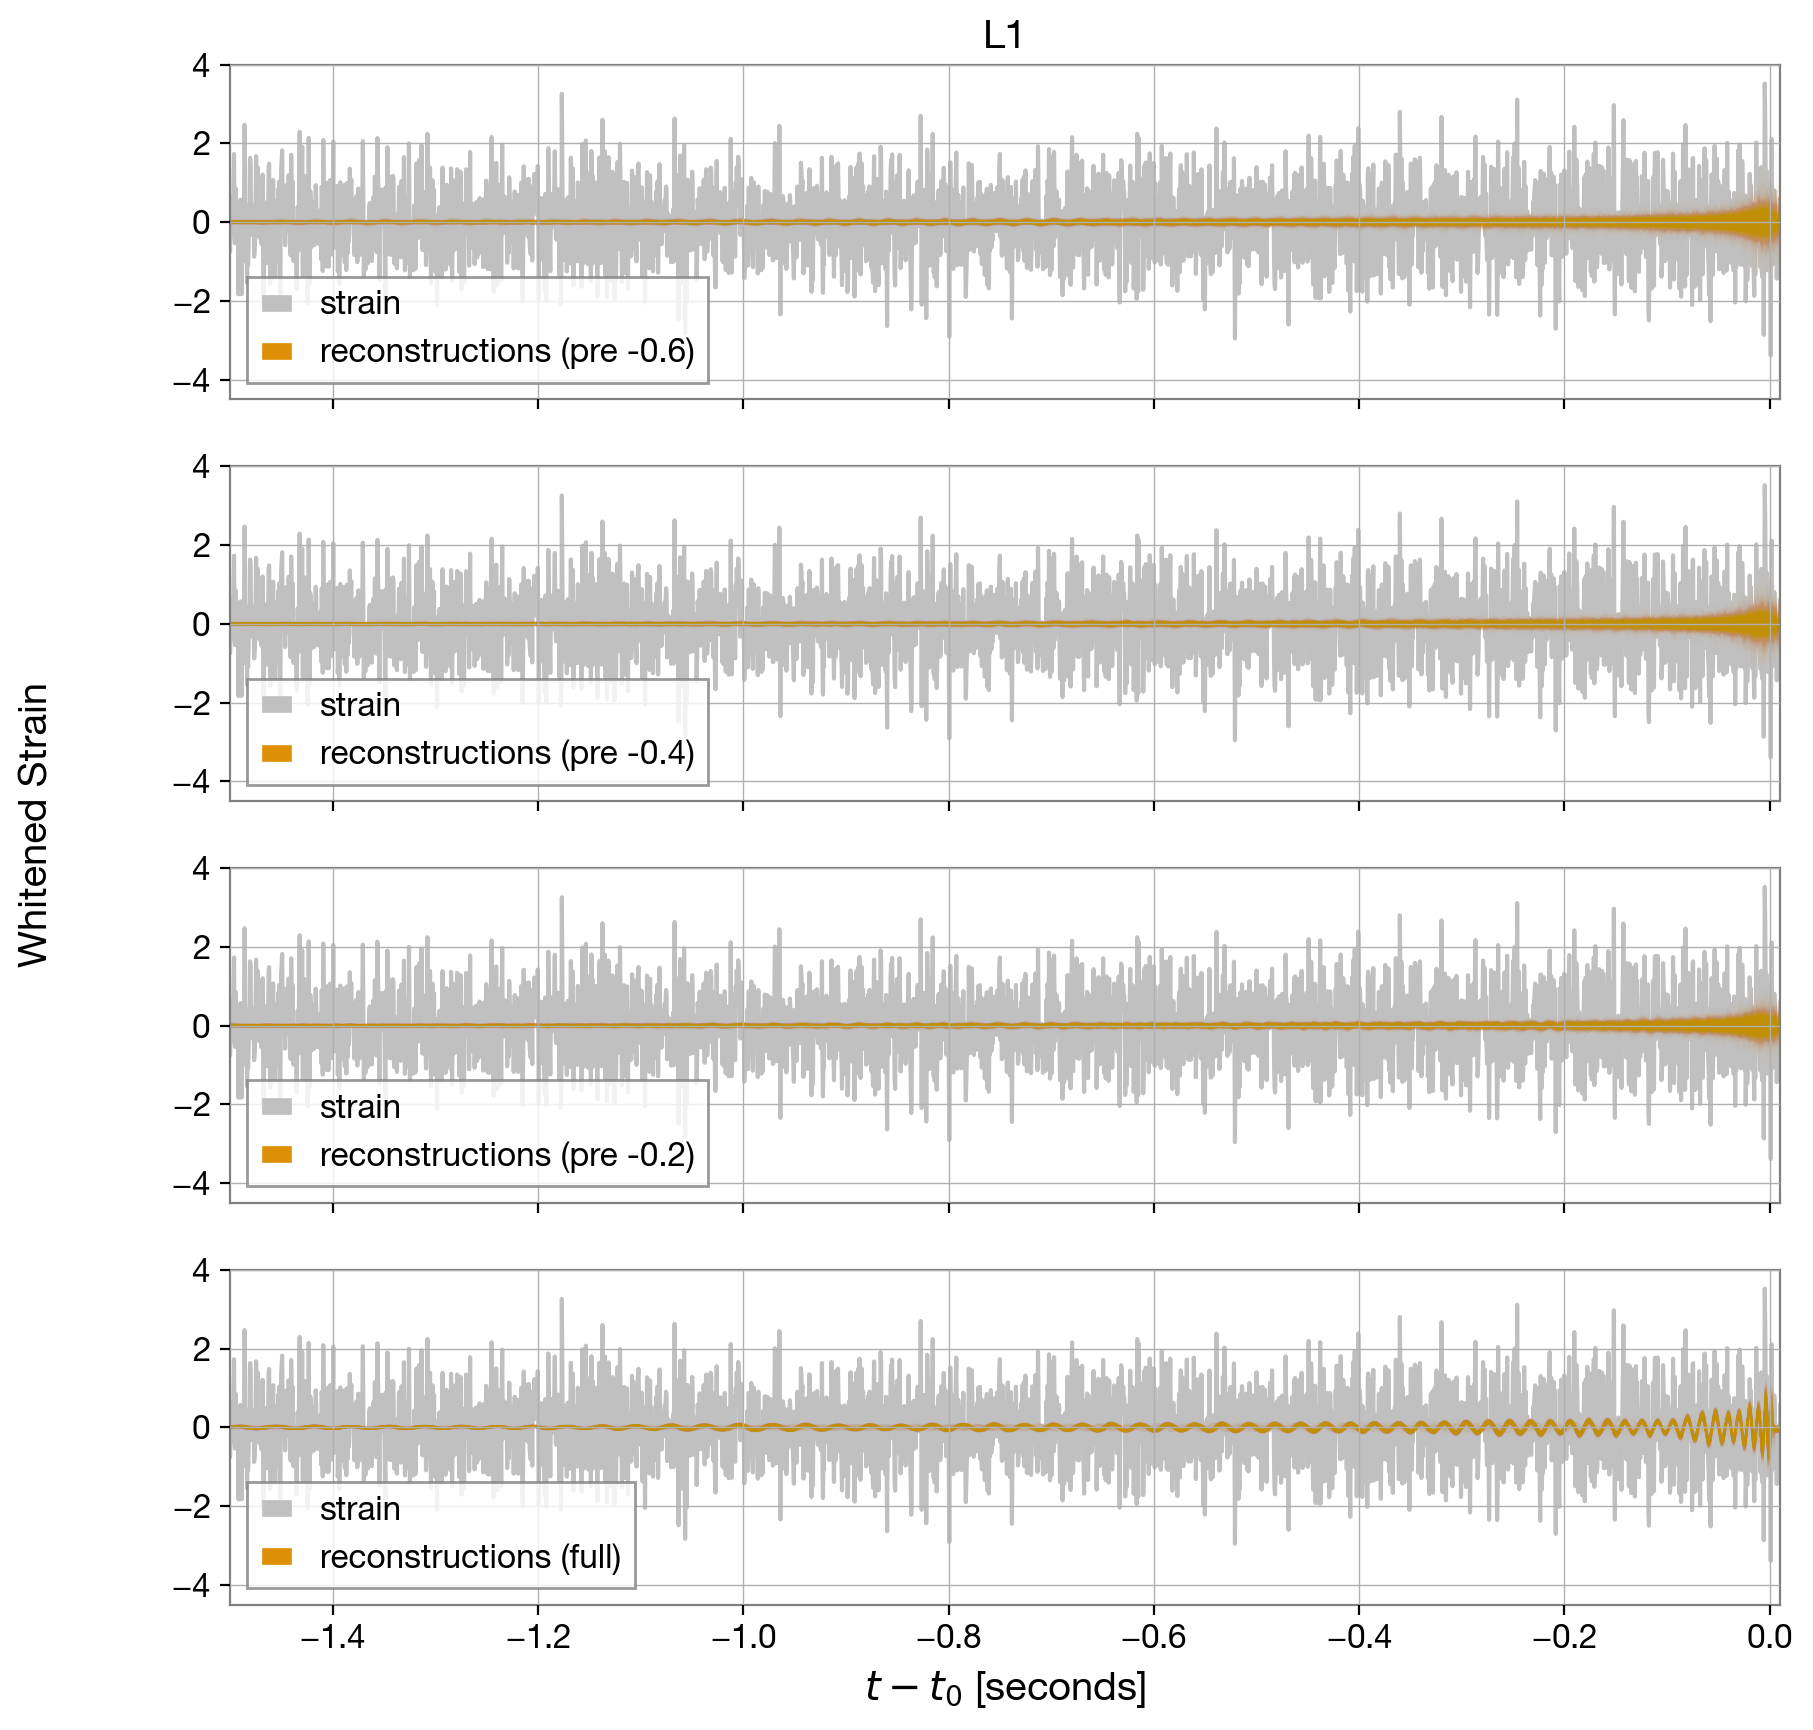

In [14]:
for i, ifo in enumerate(lm.ifos): 

    fig, axes = plt.subplots(4, 1, sharey=True, sharex=True, figsize=(10, 10))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]

    ylim_dict = {'H1': (-3.5, 3.5), 'L1': (-4.5, 4)}
    
    axes[0].set_title(ifo)
    axes[0].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_6_whitened)):
        axes[0].plot(time_from_merger, wfs_6_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (pre -0.6)')]
    axes[0].legend(handles=handles)
    axes[0].set_xlim(-1.5, 0.01)
    axes[0].set_ylim(ylim_dict[ifo])

    axes[1].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_4_whitened)):
        axes[1].plot(time_from_merger, wfs_4_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (pre -0.4)')]
    axes[1].legend(handles=handles)
    axes[1].set_xlim(-1.5, 0.01)
    axes[1].set_ylim(ylim_dict[ifo])
    
    axes[2].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_2_whitened)):
        axes[2].plot(time_from_merger, wfs_2_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (pre -0.2)')]
    axes[2].legend(handles=handles)    
    axes[2].set_xlim(-1.5, 0.01)
    axes[2].set_ylim(ylim_dict[ifo])
    
    axes[3].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_full_whitened)):
        axes[3].plot(time_from_merger, wfs_full_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    axes[3].legend(handles=handles)
    axes[3].set_xlim(-1.5, 0.01)
    axes[3].set_ylim(ylim_dict[ifo])

    plt.xlabel('$t-t_0$ [seconds]')
    fig.supylabel('Whitened Strain')
    plt.show()

In [15]:
total_mass, mass_ratio, luminosity_distance, inclination, spin1_magnitude, spin2_magnitude = np.loadtxt("output/full_0.0seconds/full_0.0seconds.dat", skiprows=1, unpack=True, usecols=(3, 4, 5, 6, 7, 8))

In [16]:
params = ["total_mass", "mass_ratio", "luminosity_distance", "inclination", "spin1_magnitude", "spin2_magnitude"]

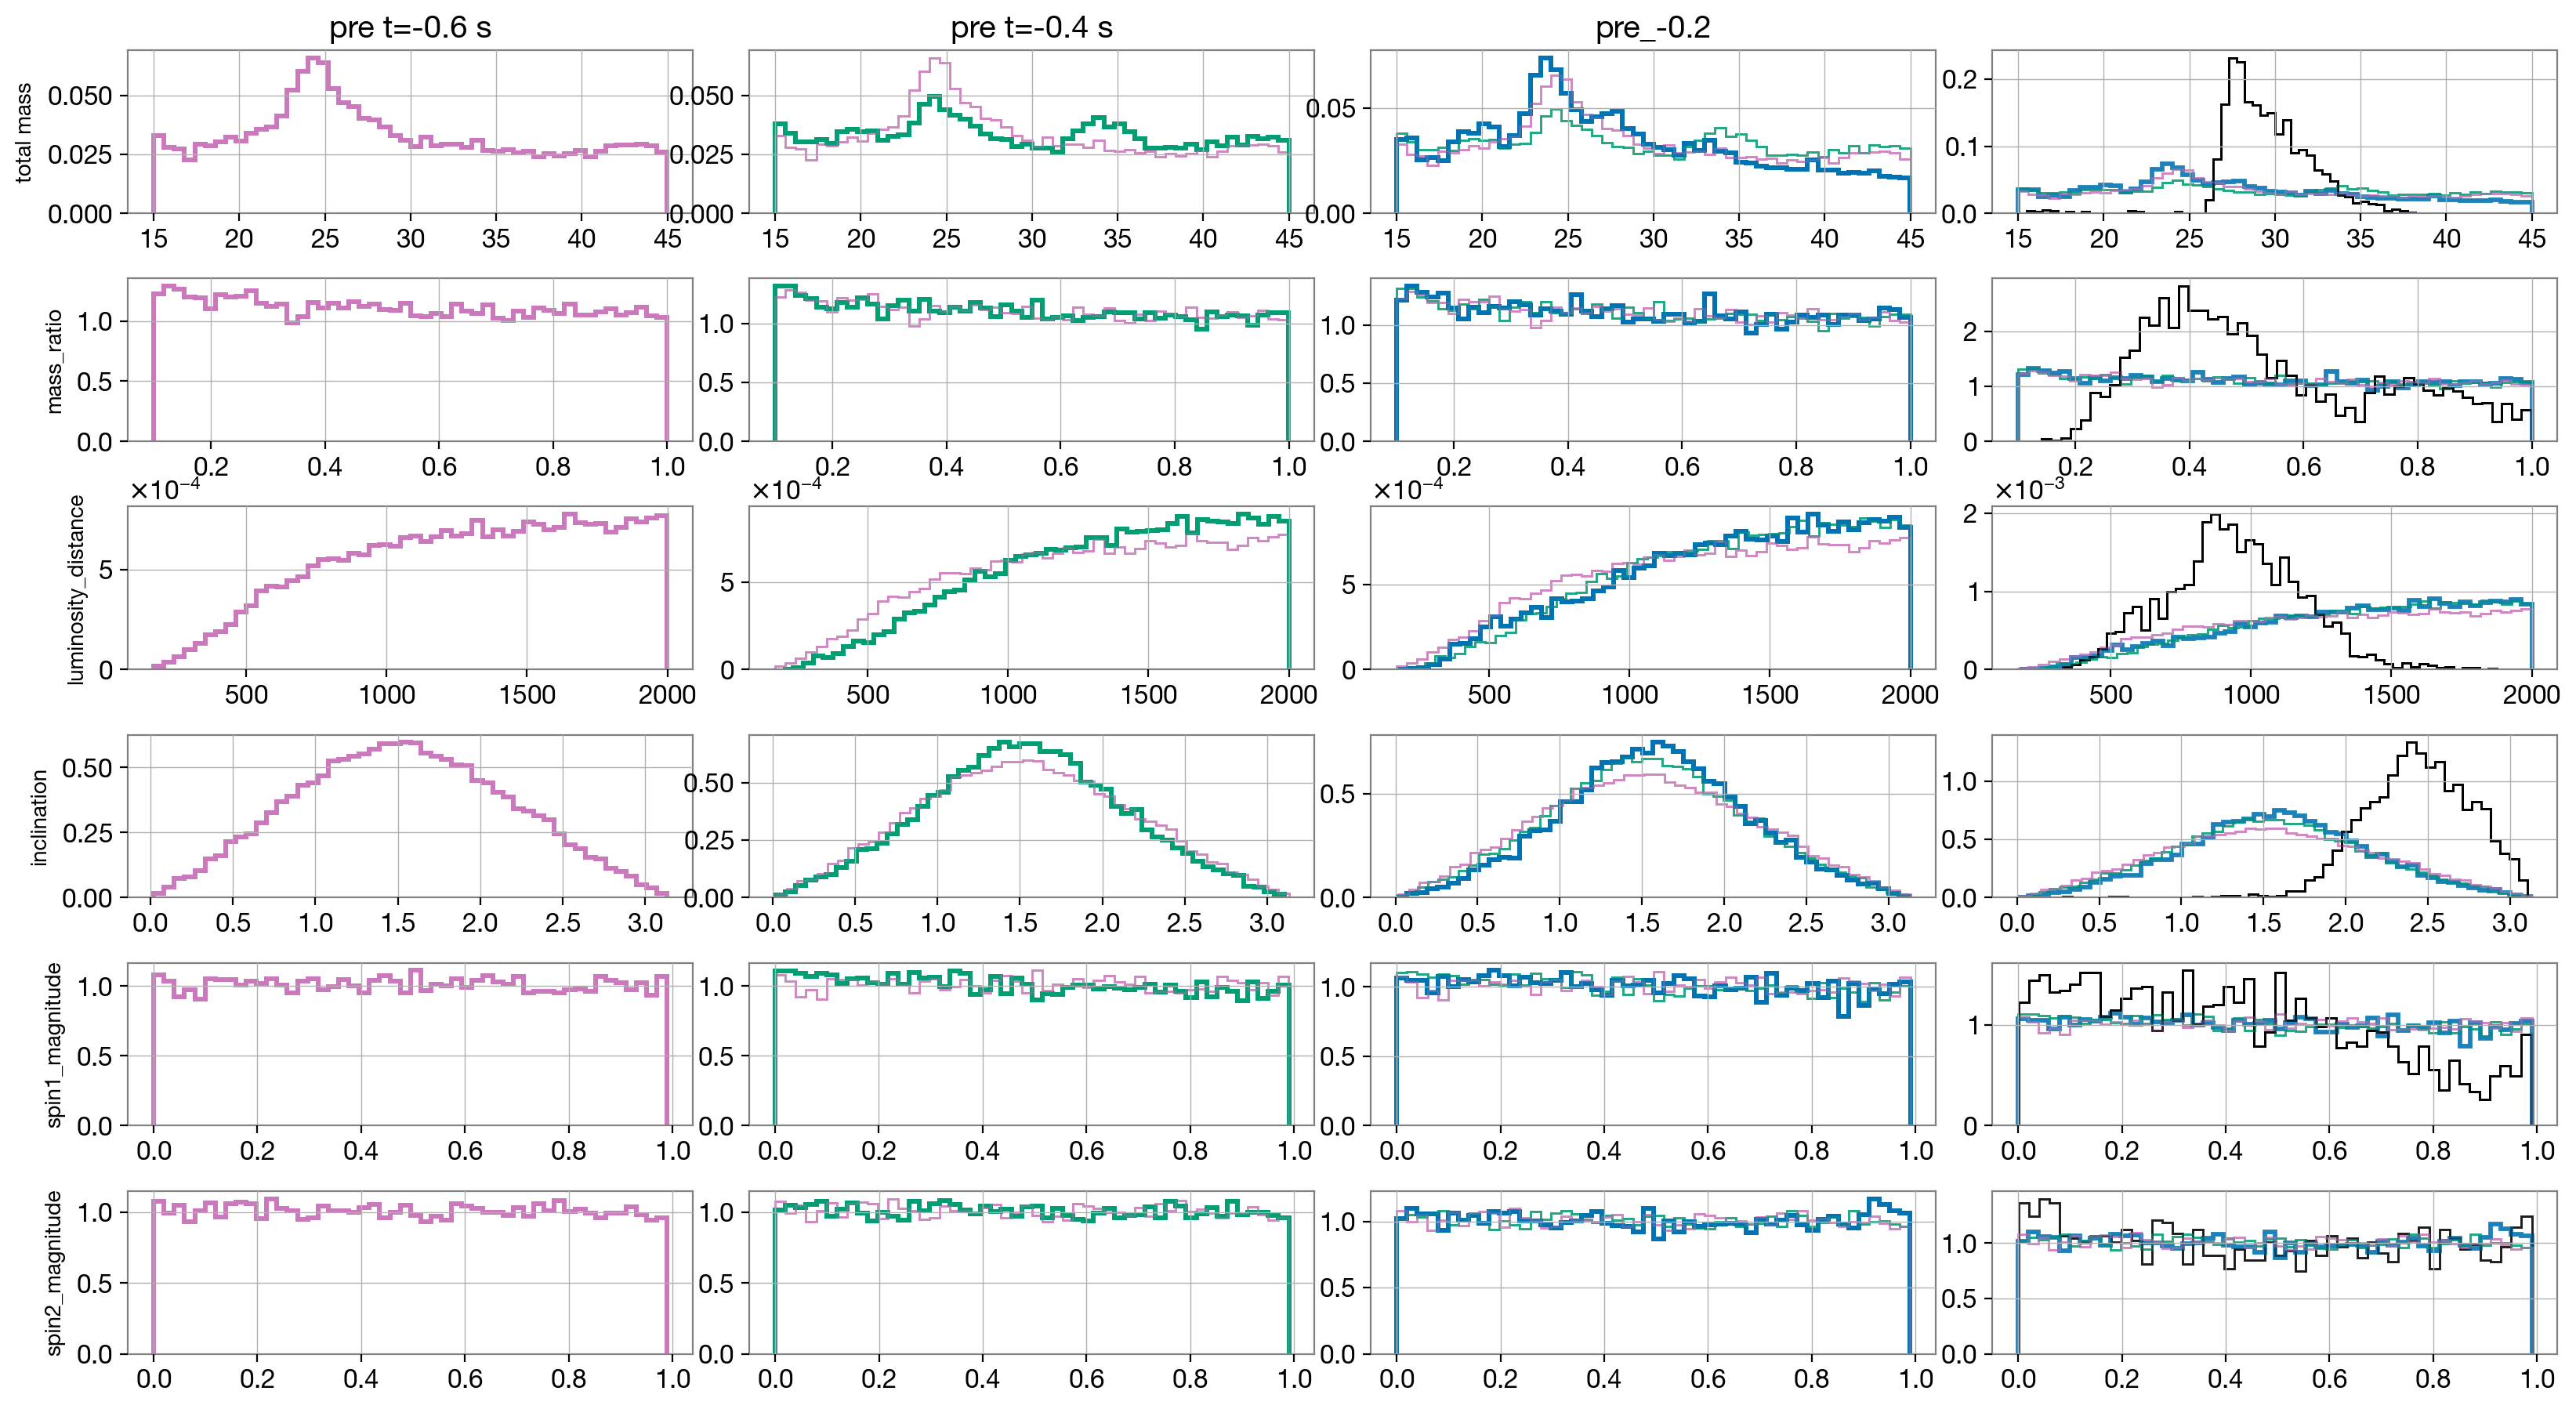

In [23]:
fig, axes = plt.subplots(6, 4, figsize=(20, 6 * 1.8))

for row, p in enumerate(params):

    axes[0,0].hist(result['dfs']['pre_-0.6']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='C4')
    axes[0,0].set_title('pre t=-0.6 s')
    axes[0,0].set_ylabel('total mass', fontsize=10)
    axes[0,1].hist(result['dfs']['pre_-0.4']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='C2')
    axes[0,1].hist(result['dfs']['pre_-0.6']['total_mass'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3)
    axes[0,1].set_title('pre t=-0.4 s')
    axes[0,2].hist(result['dfs']['pre_-0.2']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='C0')
    axes[0,2].hist(result['dfs']['pre_-0.4']['total_mass'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[0,2].hist(result['dfs']['pre_-0.6']['total_mass'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)
    axes[0,2].set_title('pre_-0.2')
    axes[0,3].hist(result['dfs']['full']['total_mass'], density=True, histtype='step', bins=50, color='k')
    axes[0,3].hist(result['dfs']['pre_-0.2']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='C0', alpha=0.3)
    axes[0,3].hist(result['dfs']['pre_-0.4']['total_mass'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[0,3].hist(result['dfs']['pre_-0.6']['total_mass'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)


    axes[1,0].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C4')
    axes[1,0].set_ylabel('mass_ratio', fontsize=10)
    axes[1,1].hist(result['dfs']['pre_-0.4']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C2')
    axes[1,1].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3)
    axes[1,2].hist(result['dfs']['pre_-0.2']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C0')
    axes[1,2].hist(result['dfs']['pre_-0.4']['mass_ratio'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[1,2].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)
    axes[1,3].hist(result['dfs']['full']['mass_ratio'], density=True, histtype='step', bins=50, color='k')
    axes[1,3].hist(result['dfs']['pre_-0.2']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C0', alpha=0.3)
    axes[1,3].hist(result['dfs']['pre_-0.4']['mass_ratio'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[1,3].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)

    axes[2,0].hist(result['dfs']['pre_-0.6']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='C4')
    axes[2,0].set_ylabel('luminosity_distance', fontsize=10)
    axes[2,1].hist(result['dfs']['pre_-0.4']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='C2')
    axes[2,1].hist(result['dfs']['pre_-0.6']['luminosity_distance'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3)
    axes[2,2].hist(result['dfs']['pre_-0.2']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='C0')
    axes[2,2].hist(result['dfs']['pre_-0.4']['luminosity_distance'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[2,2].hist(result['dfs']['pre_-0.6']['luminosity_distance'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)
    axes[2,3].hist(result['dfs']['full']['luminosity_distance'], density=True, histtype='step', bins=50, color='k')
    axes[2,3].hist(result['dfs']['pre_-0.2']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='C0', alpha=0.3)
    axes[2,3].hist(result['dfs']['pre_-0.4']['luminosity_distance'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[2,3].hist(result['dfs']['pre_-0.6']['luminosity_distance'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)

    axes[3,0].hist(result['dfs']['pre_-0.6']['inclination'], density=True, histtype='step', bins=50, lw=2, color='C4')
    axes[3,0].set_ylabel('inclination', fontsize=10)
    axes[3,1].hist(result['dfs']['pre_-0.4']['inclination'], density=True, histtype='step', bins=50, lw=2, color='C2')
    axes[3,1].hist(result['dfs']['pre_-0.6']['inclination'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3)
    axes[3,2].hist(result['dfs']['pre_-0.2']['inclination'], density=True, histtype='step', bins=50, lw=2, color='C0')
    axes[3,2].hist(result['dfs']['pre_-0.4']['inclination'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[3,2].hist(result['dfs']['pre_-0.6']['inclination'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)
    axes[3,3].hist(result['dfs']['full']['inclination'], density=True, histtype='step', bins=50, color='k')
    axes[3,3].hist(result['dfs']['pre_-0.2']['inclination'], density=True, histtype='step', bins=50, lw=2, color='C0', alpha=0.3)
    axes[3,3].hist(result['dfs']['pre_-0.4']['inclination'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[3,3].hist(result['dfs']['pre_-0.6']['inclination'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)

    axes[4,0].hist(result['dfs']['pre_-0.6']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C4')
    axes[4,0].set_ylabel('spin1_magnitude', fontsize=10)
    axes[4,1].hist(result['dfs']['pre_-0.4']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C2')
    axes[4,1].hist(result['dfs']['pre_-0.6']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3)
    axes[4,2].hist(result['dfs']['pre_-0.2']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C0')
    axes[4,2].hist(result['dfs']['pre_-0.4']['spin1_magnitude'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[4,2].hist(result['dfs']['pre_-0.6']['spin1_magnitude'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)
    axes[4,3].hist(result['dfs']['full']['spin1_magnitude'], density=True, histtype='step', bins=50, color='k')
    axes[4,3].hist(result['dfs']['pre_-0.2']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C0', alpha=0.3)
    axes[4,3].hist(result['dfs']['pre_-0.4']['spin1_magnitude'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[4,3].hist(result['dfs']['pre_-0.6']['spin1_magnitude'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)

    axes[5,0].hist(result['dfs']['pre_-0.6']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C4')
    axes[5,0].set_ylabel('spin2_magnitude', fontsize=10)
    axes[5,1].hist(result['dfs']['pre_-0.4']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C2')
    axes[5,1].hist(result['dfs']['pre_-0.6']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3)
    axes[5,2].hist(result['dfs']['pre_-0.2']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C0')
    axes[5,2].hist(result['dfs']['pre_-0.4']['spin2_magnitude'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[5,2].hist(result['dfs']['pre_-0.6']['spin2_magnitude'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)
    axes[5,3].hist(result['dfs']['full']['spin2_magnitude'], density=True, histtype='step', bins=50, color='k', alpha=0.3)    
    axes[5,3].hist(result['dfs']['pre_-0.2']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C0', alpha=0.3)
    axes[5,3].hist(result['dfs']['pre_-0.4']['spin2_magnitude'], density=True, histtype='step', bins=50, color='C2', alpha=0.3)
    axes[5,3].hist(result['dfs']['pre_-0.6']['spin2_magnitude'], density=True, histtype='step', bins=50, color='C4', alpha=0.3)

plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

In [24]:
times = ['pre_-0.6', 'pre_-0.4', 'pre_-0.2', 'full']
chi_eff = {}
chi_p = {}

for t in times:
    mass_ratio = result['dfs'][t]['mass_ratio']
    spin1_z = result['dfs'][t]['spin1_z']
    spin2_z = result['dfs'][t]['spin2_z']
    tilt1 = result['dfs'][t]['tilt1']
    tilt2 = result['dfs'][t]['tilt2']
    spin1_magnitude = result['dfs'][t]['spin1_magnitude']
    spin2_magnitude = result['dfs'][t]['spin2_magnitude']

    chi_eff[t] = (spin1_z + mass_ratio * spin2_z)/(1 + mass_ratio)
    chi_p[t] = np.maximum(spin1_magnitude * np.sin(tilt1), (3 + 4 * mass_ratio) / (4 + 3 * mass_ratio) * mass_ratio * spin2_magnitude * np.sin(tilt2))

print(chi_eff['pre_-0.6'])
print(chi_eff['pre_-0.4'])
print(chi_eff['pre_-0.2'])
print(chi_eff['full'])

0       -0.056236
1       -0.028554
2        0.156776
3        0.404106
4       -0.330207
           ...   
30459    0.363439
30460    0.198793
30461    0.383589
30462    0.216017
30463    0.040006
Length: 30464, dtype: float64
0        0.366241
1       -0.167026
2        0.071376
3       -0.159242
4        0.259175
           ...   
28667   -0.186824
28668    0.088114
28669   -0.039021
28670    0.327029
28671   -0.151457
Length: 28672, dtype: float64
0        0.088282
1        0.404150
2        0.289857
3        0.615410
4       -0.161144
           ...   
18427   -0.048372
18428   -0.226681
18429   -0.029402
18430   -0.048839
18431   -0.337543
Length: 18432, dtype: float64
0      -0.036214
1       0.417498
2      -0.013083
3      -0.055086
4      -0.180199
          ...   
2555   -0.222030
2556   -0.220917
2557    0.053151
2558   -0.341528
2559   -0.059591
Length: 2560, dtype: float64


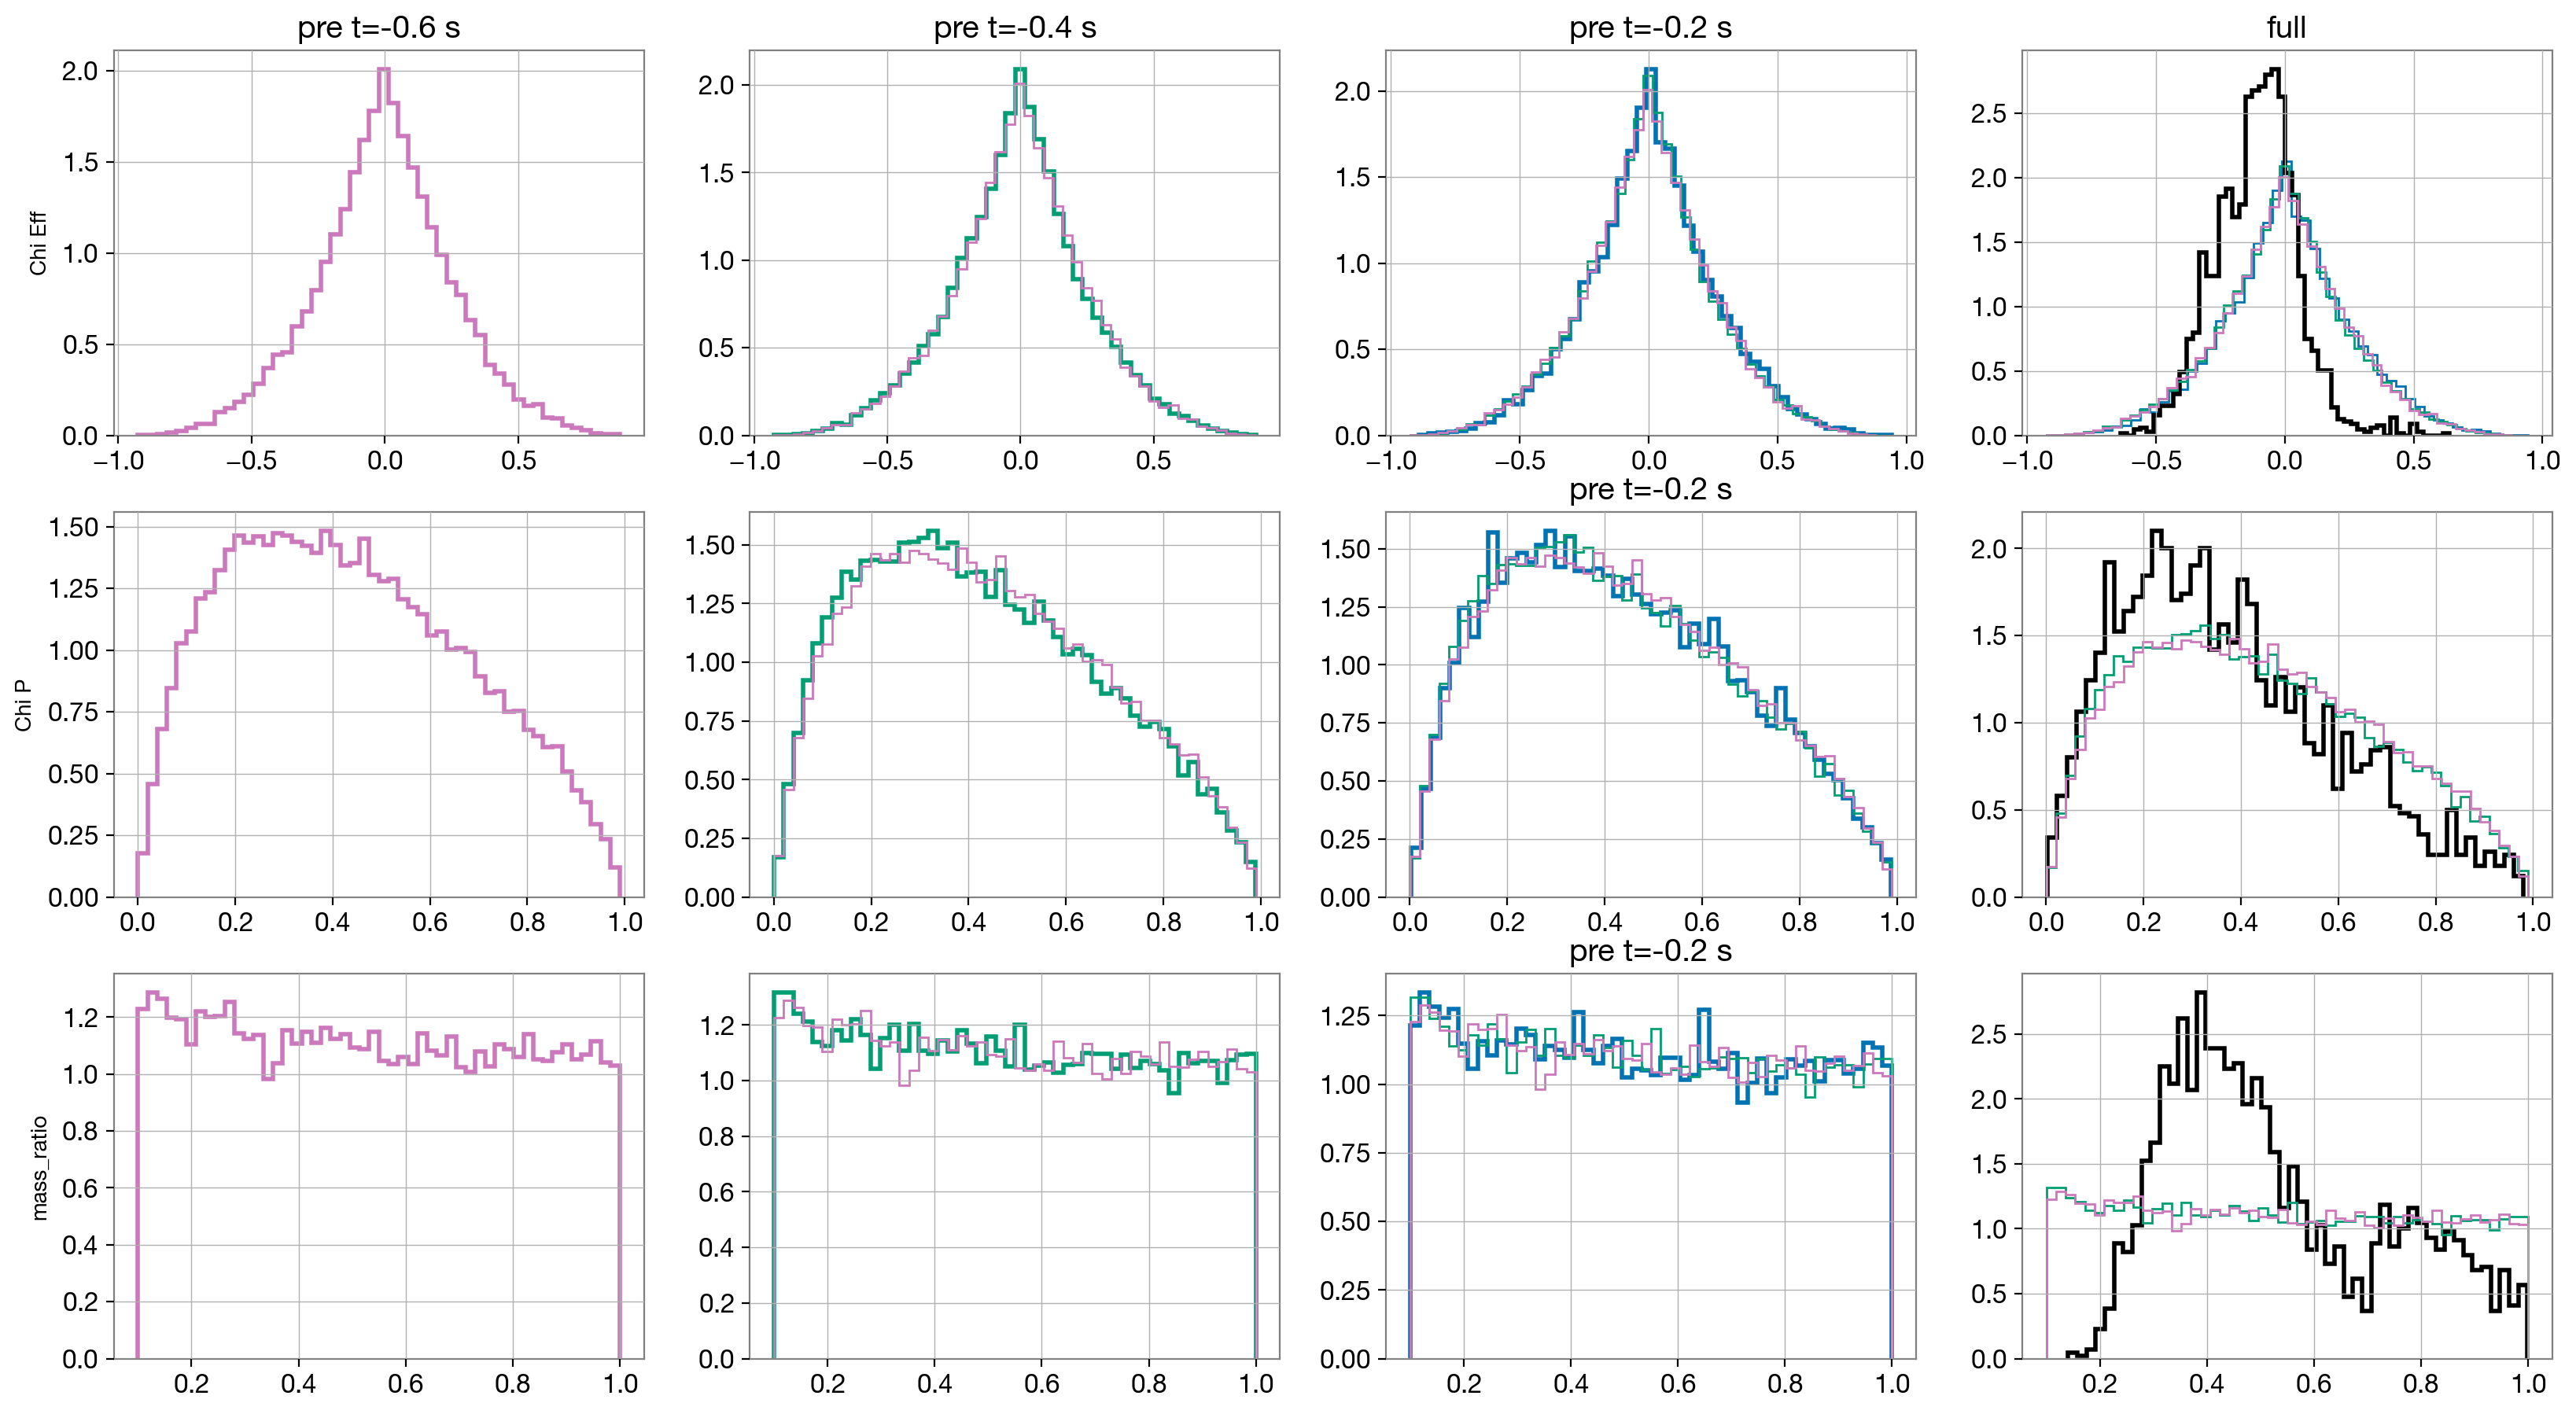

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(20, 6 * 1.8))

axes[0,0].hist(chi_eff['pre_-0.6'], density=True, histtype='step', bins=50, lw=2, color='C4')
axes[0,0].set_title('pre t=-0.6 s')
axes[0,0].set_ylabel('Chi Eff', fontsize=10)
axes[0,1].hist(chi_eff['pre_-0.4'], density=True, histtype='step', bins=50, lw=2, color='C2')
axes[0,1].hist(chi_eff['pre_-0.6'], density=True, histtype='step', bins=50, lw=1, color='C4')
axes[0,1].set_title('pre t=-0.4 s')
axes[0,2].hist(chi_eff['pre_-0.2'], density=True, histtype='step', bins=50, lw=2, color='C0')
axes[0,2].hist(chi_eff['pre_-0.4'], density=True, histtype='step', bins=50, lw=1, color='C2')
axes[0,2].hist(chi_eff['pre_-0.6'], density=True, histtype='step', bins=50, lw=1, color='C4')
axes[0,2].set_title('pre t=-0.2 s')
axes[0,3].hist(chi_eff['pre_-0.2'], density=True, histtype='step', bins=50, lw=1, color='C0')
axes[0,3].hist(chi_eff['full'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
axes[0,3].hist(chi_eff['pre_-0.4'], density=True, histtype='step', bins=50, color='C2')
axes[0,3].hist(chi_eff['pre_-0.6'], density=True, histtype='step', bins=50, color='C4')
axes[0,3].set_title('full')

axes[1,0].hist(chi_p['pre_-0.6'], density=True, histtype='step', bins=50, lw=2, color='C4')
axes[1,0].set_ylabel('Chi P', fontsize=10)
axes[1,1].hist(chi_p['pre_-0.4'], density=True, histtype='step', bins=50, lw=2, color='C2')
axes[1,1].hist(chi_p['pre_-0.6'], density=True, histtype='step', bins=50, lw=1, color='C4')
axes[1,2].hist(chi_p['pre_-0.2'], density=True, histtype='step', bins=50, lw=2, color='C0')
axes[1,2].hist(chi_p['pre_-0.4'], density=True, histtype='step', bins=50, lw=1, color='C2')
axes[1,2].hist(chi_p['pre_-0.6'], density=True, histtype='step', bins=50, lw=1, color='C4')
axes[1,2].set_title('pre t=-0.2 s')
axes[1,3].hist(chi_p['full'], density=True, histtype='step', bins=50, lw=2, color='k')
axes[1,3].hist(chi_p['pre_-0.4'], density=True, histtype='step', bins=50, color='C2')
axes[1,3].hist(chi_p['pre_-0.6'], density=True, histtype='step', bins=50, color='C4')

axes[2,0].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C4')
axes[2,0].set_ylabel('mass_ratio', fontsize=10)
axes[2,1].hist(result['dfs']['pre_-0.4']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C2')
axes[2,1].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, lw=1, color='C4')
axes[2,2].hist(result['dfs']['pre_-0.2']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C0')
axes[2,2].hist(result['dfs']['pre_-0.4']['mass_ratio'], density=True, histtype='step', bins=50, lw=1, color='C2')
axes[2,2].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, lw=1, color='C4')
axes[2,2].set_title('pre t=-0.2 s')
axes[2,3].hist(result['dfs']['full']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='k')
axes[2,3].hist(result['dfs']['pre_-0.4']['mass_ratio'], density=True, histtype='step', bins=50, color='C2')
axes[2,3].hist(result['dfs']['pre_-0.6']['mass_ratio'], density=True, histtype='step', bins=50, color='C4')

plt.show()

### If you have any further questions about running `tdinf` or plotting/interpreting results, reach out to `simona.miller@ligo.org`.